# Proyecto Final – Telecomunicaciones

📎 **Enlace al archivo .ipynb en Google Drive (para revisión):**  
https://drive.google.com/drive/folders/1bakmENIzhrKxv-oi-HUKUdFN0ntquisv?usp=drive_link

📄 **Presentación en PDF:**  
https://drive.google.com/file/d/11ImeLXTgCoK0GzwLLaidabFCDLIEpJBI/view?usp=sharing

📊 **Dashboard en Tableau Public:**  
https://public.tableau.com/app/profile/cristian.galvez/viz/Proyecto_Final_Telecom_Operadores_Ineficientes/Dashboard-DesempeodeOperadores

📂 **Organización del proyecto**

El notebook `Proyecto_Final_Telecom.ipynb` se encuentra en la misma carpeta que los archivos de datos:

- `telecom_dataset_new.csv` — Dataset principal con registros de llamadas.
- `telecom_clients.csv` — Información complementaria sobre los clientes.
- `CA.pem` — Certificado SSL utilizado en el intento inicial de conexión a base de datos (conservado como referencia).

Al estar en la misma ubicación, los archivos pueden cargarse mediante rutas relativas simples, como:

```python
pd.read_csv('telecom_dataset_new.csv')


In [35]:
# =========================
# Importar librerías
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from scipy import stats

# Ajustes de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Estilo básico de gráficos
sns.set(style='whitegrid')


In [36]:
# =========================
# Conexión a la base de datos
# =========================

db_config = {
    'user': 'practicum_student',          # nombre de usuario
    'pwd': 's65BlTKV3faNIGhmvJVzOqhs',    # contraseña
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,                         # puerto de conexión
    'db': 'data-analyst-final-project-db' # nombre de la base de datos
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(
    connection_string,
    connect_args={
        'sslmode': 'require',
        'sslrootcert': 'CA.pem'  # certificado que acabas de guardar
    }
)


In [37]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("SELECT 1 AS test_col;"))
    print(result.fetchall())


[(1,)]


 Nota sobre el acceso a los datos

Inicialmente se intentó acceder a los datos mediante conexión SQL, según las instrucciones del proyecto, utilizando el certificado SSL (CA.pem) y el motor SQLAlchemy. Sin embargo, al explorar los esquemas accesibles en la base de datos remota, se confirmó que los datos del proyecto final (telecom_dataset y telecom_clients) no están alojados en dicha base, sino exclusivamente disponibles como archivos CSV.

Por lo tanto, a partir de este punto, el análisis se desarrolla utilizando los archivos locales
telecom_dataset_new.csv y telecom_clients.csv, manteniendo exactamente las mismas estructuras y objetivos del proyecto.

In [38]:
import os

print(os.listdir())

df_calls = pd.read_csv('telecom_dataset_new.csv')
df_clients = pd.read_csv('telecom_clients.csv')

['CA.pem', 'dashboard.txt', 'operator_stats.csv', 'Proyecto_Final.pdf', 'Proyecto_Final_Telecom.ipynb', 'README.md', 'telecom_clients.csv', 'telecom_dataset_new.csv']


In [39]:
# =========================
# Cargar datos desde archivos CSV
# =========================

df_calls = pd.read_csv('telecom_dataset_new.csv')
df_clients = pd.read_csv('telecom_clients.csv')

print("df_calls shape:", df_calls.shape)
print("df_clients shape:", df_clients.shape)

display(df_calls.head())
display(df_clients.head())


df_calls shape: (53902, 9)
df_clients shape: (732, 3)


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,"880,022.00",True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,"880,020.00",True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,"880,020.00",False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,"880,022.00",True,3,0,25


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [40]:
df_calls.info()
df_clients.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2 

Introducción técnica y decisión metodológica

En las instrucciones iniciales del proyecto se indica que es posible acceder a los datos mediante conexión SQL utilizando un motor PostgreSQL y el certificado de seguridad CA.pem. Por esta razón, se intentó inicialmente explorar la base de datos remota con las credenciales proporcionadas, verificando los esquemas y tablas disponibles mediante consultas a information_schema.tables.

Sin embargo, tras revisar los esquemas accesibles (public, pg_catalog, information_schema) y aplicar filtros sobre nombres relacionados con telecom, calls, clients y operators, se confirmó que las tablas del proyecto (telecom_dataset_us, telecom_clients_us) no están alojadas en la base de datos remota, sino que están disponibles exclusivamente como archivos CSV locales.

Por lo tanto, para este análisis se decidió utilizar los archivos:

telecom_dataset_new.csv: contiene los registros de llamadas.

telecom_clients.csv: contiene información de clientes y planes tarifarios.

Esto sigue siendo totalmente válido y consistente con las instrucciones del proyecto, ya que estos CSV contienen la estructura oficial descrita y permiten desarrollar el análisis completo, incluyendo:

✔ Exploración de datos (EDA)

✔ Identificación de operadores ineficaces

✔ Prueba de hipótesis estadísticas

✔ Construcción de métricas operativas

A partir de esta sección, el análisis se desarrolla íntegramente con pandas, usando estos archivos como fuente de datos principal.

Objetivo del análisis

El propósito es identificar operadores ineficaces, considerando especialmente:

Criterio	Indicador
Calidad de atención (entrantes)	% de llamadas perdidas
Eficiencia operativa	Tiempo de espera antes de contestar
Productividad (salientes)	Cantidad de llamadas realizadas
Interacción interna	Llamadas entre operadores

In [41]:
# =========================
# Exploración básica de df_calls
# =========================

print("Columnas de df_calls:", df_calls.columns.tolist())

print("\nValores únicos en 'direction':", df_calls['direction'].unique())
print("Valores únicos en 'internal':", df_calls['internal'].unique())
print("Valores únicos en 'is_missed_call':", df_calls['is_missed_call'].unique())

print("\nCantidad de valores nulos por columna:")
print(df_calls.isnull().sum())

print("\nEjemplos de filas con operator_id nulo:")
display(df_calls[df_calls['operator_id'].isna()].head())

print("\nEjemplos de filas con llamadas perdidas:")
display(df_calls[df_calls['is_missed_call'] == True].head())


Columnas de df_calls: ['user_id', 'date', 'direction', 'internal', 'operator_id', 'is_missed_call', 'calls_count', 'call_duration', 'total_call_duration']

Valores únicos en 'direction': ['in' 'out']
Valores únicos en 'internal': [False True nan]
Valores únicos en 'is_missed_call': [ True False]

Cantidad de valores nulos por columna:
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Ejemplos de filas con operator_id nulo:


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
17,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
27,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34



Ejemplos de filas con llamadas perdidas:


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,"880,022.00",True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,"880,020.00",True,1,0,1
4,166377,2019-08-05 00:00:00+03:00,out,False,"880,022.00",True,3,0,25
6,166377,2019-08-05 00:00:00+03:00,out,False,"880,020.00",True,8,0,50


In [42]:
# =========================
# Crear variable de tiempo de espera
# =========================

df_calls['waiting_time'] = df_calls['total_call_duration'] - df_calls['call_duration']

print("Valores estadísticos de waiting_time:")
print(df_calls['waiting_time'].describe())

# Verificar algunos ejemplos
display(df_calls[['call_duration', 'total_call_duration', 'waiting_time']].head(10))


Valores estadísticos de waiting_time:


count   53,902.00
mean       290.45
std      1,127.91
min          0.00
25%         17.00
50%         55.00
75%        201.00
max     46,474.00
Name: waiting_time, dtype: float64


,call_duration,total_call_duration,waiting_time
0,0,4,4
1,0,5,5
2,0,1,1
3,10,18,8
4,0,25,25
5,3,29,26
6,0,50,50
7,0,35,35
8,0,50,50
9,0,62,62


In [43]:
# =========================
# Convertir las fechas a tipo datetime
# =========================

df_calls['date'] = pd.to_datetime(df_calls['date'], errors='coerce')
df_clients['date_start'] = pd.to_datetime(df_clients['date_start'], errors='coerce')

df_calls['date'].head(), df_clients['date_start'].head()


(0   2019-08-04 00:00:00+03:00
 1   2019-08-05 00:00:00+03:00
 2   2019-08-05 00:00:00+03:00
 3   2019-08-05 00:00:00+03:00
 4   2019-08-05 00:00:00+03:00
 Name: date, dtype: datetime64[ns, UTC+03:00],
 0   2019-08-15
 1   2019-08-23
 2   2019-10-29
 3   2019-09-01
 4   2019-10-16
 Name: date_start, dtype: datetime64[ns])

In [44]:
# =========================
# Crear resumen de métricas por operador
# =========================

# Filtramos solo las filas que tienen operador asignado
df_ops = df_calls[df_calls['operator_id'].notna()].copy()

# Agrupamos por operator_id
operator_stats = df_ops.groupby('operator_id').agg(
    total_calls=('calls_count', 'sum'),
    missed_calls=('is_missed_call', 'sum'),
    missed_call_rate=('is_missed_call', 'mean'),
    avg_waiting_time=('waiting_time', 'mean'),
    outbound_calls=('direction', lambda x: (x == 'out').sum()),
    internal_call_rate=('internal', lambda x: x.mean()),
    avg_call_duration=('call_duration', 'mean')
).reset_index()

operator_stats.head()


,operator_id,total_calls,missed_calls,missed_call_rate,avg_waiting_time,outbound_calls,internal_call_rate,avg_call_duration
0,"879,896.00",1131,50,0.39,110.67,105,0.12,650.48
1,"879,898.00",7974,100,0.40,450.09,187,0.06,"1,111.07"
2,"880,020.00",54,7,0.32,15.18,14,0.14,104.09
3,"880,022.00",219,33,0.43,57.57,68,0.11,240.84
4,"880,026.00",2439,94,0.47,121.17,179,0.07,856.94


Hallazgos Clave — Eficiencia Operativa Inicial por Operador

A partir del análisis inicial de los registros de llamadas, se identificaron los siguientes puntos relevantes:

1. Estructura y comportamiento de los datos

Las llamadas incluyen información sobre dirección (in/out), si son internas (internal) y si fueron atendidas o perdidas.

Se observan valores nulos en operator_id, correspondientes principalmente a llamadas entrantes no atendidas, lo que indica que no fueron asignadas a ningún operador.

Las llamadas perdidas tienen call_duration = 0, pero sí presentan tiempo de espera (total_call_duration > 0), lo que confirma que el cliente esperó pero no recibió atención.

2. Interpretación del tiempo de espera (waiting_time)

Se creó la variable waiting_time como:

waiting_time = total_call_duration - call_duration


Valores destacados:

Métrica	Valor
Mediana (50%)	55 segundos
Q3 (75%)	201 segundos
Máximo	46,474 segundos (≈12.9 horas)

Esto indica:

Muchas llamadas tienen tiempos razonables de espera.

Sin embargo, existe un grupo significativo con esperas muy prolongadas, lo que podría estar relacionado con operadores ineficaces o procesos de atención deficientes.

Existen outliers extremos que deberán revisarse o tratarse.

 3. Primeras métricas de desempeño por operador

Para cada operador se calcularon:

Métrica	Descripción
missed_call_rate	Porcentaje de llamadas perdidas
avg_waiting_time	Tiempo promedio que el cliente esperó antes de ser atendido
outbound_calls	Número de llamadas salientes realizadas (productividad)
internal_call_rate	Proporción de llamadas internas
avg_call_duration	Duración promedio de llamadas atendidas
 Ejemplos preliminares:
operator_id	missed_call_rate	avg_waiting_time (s)	outbound_calls	Observación
879,896	39%	110 s	105	Alta pérdida de llamadas, espera moderada
879,898	40%	450 s	187	Muy ineficaz: alta pérdida + espera muy prolongada
880,026	47%	121 s	179	Alto nivel de llamadas perdidas
880,022	43%	57 s	68	Alta pérdida, pero espera moderada
 Indicadores tempranos de ineficiencia operacional

Se consideran indicadores de posible ineficiencia:

Condición	Señal de
missed_call_rate > 40%	Atención ineficaz
avg_waiting_time > 200 sed	Mala gestión de espera
outbound_calls muy bajos	Baja productividad si se supone que debe generar llamadas
total_calls muy bajos	Información insuficiente para evaluar

 Con base en esto, el operador 879,898 destaca como altamente ineficaz, presentando simultáneamente:

Alto porcentaje de llamadas perdidas

Tiempo de espera promedio muy elevado

Buen volumen de llamadas significa que la métrica es confiable

In [45]:
# =========================
# Clasificar operadores según criterios de ineficiencia
# =========================

def classify_operator(row):
    if row['missed_call_rate'] > 0.40 and row['avg_waiting_time'] > 200:
        return 'Muy ineficaz'
    elif row['missed_call_rate'] > 0.40 or row['avg_waiting_time'] > 200:
        return 'Ineficaz parcial'
    elif row['missed_call_rate'] <= 0.25 and row['avg_waiting_time'] <= 100:
        return 'Eficiente'
    else:
        return 'Zona media'

# Crear nueva columna de clasificación
operator_stats['classification'] = operator_stats.apply(classify_operator, axis=1)

# Ver primeros registros clasificados
display(operator_stats.head(10))

# Conteo por categoría
print("\nCantidad de operadores por categoría:")
print(operator_stats['classification'].value_counts())


,operator_id,total_calls,missed_calls,missed_call_rate,avg_waiting_time,outbound_calls,internal_call_rate,avg_call_duration,classification
0,"879,896.00",1131,50,0.39,110.67,105,0.12,650.48,Zona media
1,"879,898.00",7974,100,0.40,450.09,187,0.06,"1,111.07",Ineficaz parcial
2,"880,020.00",54,7,0.32,15.18,14,0.14,104.09,Zona media
3,"880,022.00",219,33,0.43,57.57,68,0.11,240.84,Ineficaz parcial
4,"880,026.00",2439,94,0.47,121.17,179,0.07,856.94,Ineficaz parcial
5,"880,028.00",2906,91,0.40,210.59,181,0.04,746.27,Muy ineficaz
6,"880,240.00",49,8,0.57,40.93,14,0.43,275.93,Ineficaz parcial
7,"881,278.00",20,7,0.88,9.75,8,0.38,58.12,Ineficaz parcial
8,"882,476.00",3,0,0.00,31.67,0,0.00,64.00,Eficiente
9,"882,478.00",4,1,0.33,27.67,1,0.67,22.67,Zona media



Cantidad de operadores por categoría:
classification
Eficiente           372
Zona media          285
Ineficaz parcial    274
Muy ineficaz        161
Name: count, dtype: int64


In [46]:
display(operator_stats.head(10))

,operator_id,total_calls,missed_calls,missed_call_rate,avg_waiting_time,outbound_calls,internal_call_rate,avg_call_duration,classification
0,"879,896.00",1131,50,0.39,110.67,105,0.12,650.48,Zona media
1,"879,898.00",7974,100,0.40,450.09,187,0.06,"1,111.07",Ineficaz parcial
2,"880,020.00",54,7,0.32,15.18,14,0.14,104.09,Zona media
3,"880,022.00",219,33,0.43,57.57,68,0.11,240.84,Ineficaz parcial
4,"880,026.00",2439,94,0.47,121.17,179,0.07,856.94,Ineficaz parcial
5,"880,028.00",2906,91,0.40,210.59,181,0.04,746.27,Muy ineficaz
6,"880,240.00",49,8,0.57,40.93,14,0.43,275.93,Ineficaz parcial
7,"881,278.00",20,7,0.88,9.75,8,0.38,58.12,Ineficaz parcial
8,"882,476.00",3,0,0.00,31.67,0,0.00,64.00,Eficiente
9,"882,478.00",4,1,0.33,27.67,1,0.67,22.67,Zona media


In [47]:
operator_stats['classification'].value_counts()


classification
Eficiente           372
Zona media          285
Ineficaz parcial    274
Muy ineficaz        161
Name: count, dtype: int64

###  Resultados de la clasificación inicial de operadores

A partir de las métricas de desempeño (`missed_call_rate`, `avg_waiting_time`, `outbound_calls` y `internal_call_rate`), se estableció una clasificación de operadores según su nivel de eficiencia.

| Clasificación      | Cantidad de operadores | Interpretación |
|--------------------|------------------------|----------------|
| Muy ineficaz       | 161                    | Presentan simultáneamente una alta tasa de llamadas perdidas y tiempos de espera prolongados. Requieren intervención urgente. |
| Ineficaz parcial   | 274                    | Cumplen uno de los criterios de ineficiencia (espera elevada o muchas llamadas perdidas). |
| Zona media         | 285                    | Desempeño medio. No destacan ni como eficientes ni como ineficientes. |
| Eficiente          | 372                    | Buen desempeño general: baja pérdida de llamadas y tiempos de respuesta adecuados. |

📌 En total, **435 operadores (46.3%) muestran algún nivel de ineficiencia**, lo que representa un desafío relevante para la operación del servicio CallMeMaybe.


In [48]:
# =========================
# Seleccionar y rankear operadores ineficaces
# =========================

# Filtrar solo operadores clasificados como ineficaces
inefficient_ops = operator_stats[
    operator_stats['classification'].isin(['Muy ineficaz', 'Ineficaz parcial'])
].copy()

# Ordenar por severidad:
# 1) Primero 'Muy ineficaz'
# 2) Dentro de cada categoría, mayor missed_call_rate
# 3) Luego mayor avg_waiting_time
inefficient_ops = inefficient_ops.sort_values(
    by=['classification', 'missed_call_rate', 'avg_waiting_time'],
    ascending=[True, False, False]
)

# Mostrar los 10 operadores más problemáticos
print("Top 10 operadores ineficaces (según criterios definidos):")
display(inefficient_ops.head(10))

# Resumen de cuántos ineficientes hay por tipo
print("\nDistribución dentro de los operadores ineficientes:")
print(inefficient_ops['classification'].value_counts())

# Tamaño total del conjunto de operadores ineficientes
print("\nCantidad total de operadores ineficientes:", inefficient_ops.shape[0])


Top 10 operadores ineficaces (según criterios definidos):


,operator_id,total_calls,missed_calls,missed_call_rate,avg_waiting_time,outbound_calls,internal_call_rate,avg_call_duration,classification
324,"909,308.00",15,3,1.00,116.33,3,0.00,0.00,Ineficaz parcial
617,"932,246.00",1,1,1.00,60.00,1,0.00,0.00,Ineficaz parcial
1041,"962,904.00",2,1,1.00,43.00,1,0.00,0.00,Ineficaz parcial
697,"937,770.00",1,1,1.00,37.00,1,0.00,0.00,Ineficaz parcial
666,"936,296.00",4,3,1.00,34.67,3,0.33,0.00,Ineficaz parcial
841,"945,074.00",3,1,1.00,26.00,1,0.00,0.00,Ineficaz parcial
160,"899,076.00",2,2,1.00,23.50,2,0.50,0.00,Ineficaz parcial
92,"891,976.00",2,1,1.00,23.00,1,0.00,0.00,Ineficaz parcial
688,"937,716.00",1,1,1.00,19.00,1,0.00,0.00,Ineficaz parcial
700,"937,778.00",1,1,1.00,19.00,1,0.00,0.00,Ineficaz parcial



Distribución dentro de los operadores ineficientes:
classification
Ineficaz parcial    274
Muy ineficaz        161
Name: count, dtype: int64

Cantidad total de operadores ineficientes: 435


In [49]:
display(inefficient_ops.head(10))

inefficient_ops['classification'].value_counts()

inefficient_ops.shape[0]


,operator_id,total_calls,missed_calls,missed_call_rate,avg_waiting_time,outbound_calls,internal_call_rate,avg_call_duration,classification
324,"909,308.00",15,3,1.00,116.33,3,0.00,0.00,Ineficaz parcial
617,"932,246.00",1,1,1.00,60.00,1,0.00,0.00,Ineficaz parcial
1041,"962,904.00",2,1,1.00,43.00,1,0.00,0.00,Ineficaz parcial
697,"937,770.00",1,1,1.00,37.00,1,0.00,0.00,Ineficaz parcial
666,"936,296.00",4,3,1.00,34.67,3,0.33,0.00,Ineficaz parcial
841,"945,074.00",3,1,1.00,26.00,1,0.00,0.00,Ineficaz parcial
160,"899,076.00",2,2,1.00,23.50,2,0.50,0.00,Ineficaz parcial
92,"891,976.00",2,1,1.00,23.00,1,0.00,0.00,Ineficaz parcial
688,"937,716.00",1,1,1.00,19.00,1,0.00,0.00,Ineficaz parcial
700,"937,778.00",1,1,1.00,19.00,1,0.00,0.00,Ineficaz parcial


435

### Ranking inicial de operadores ineficaces

Tras filtrar y ordenar a los operadores clasificados como *Muy ineficaz* o *Ineficaz parcial*, se identificó un conjunto de 435 operadores con desempeño deficiente.

Los 10 casos más críticos comparten características comunes:

| Indicador | Observación |
|-----------|-------------|
| missed_call_rate | 100% (ninguna llamada atendida) |
| avg_call_duration | 0 segundos (no gestionan conversaciones) |
| outbound_calls | 1 a 3 llamadas (muy baja actividad) |
| internal_call_rate | ~0 (sin interacción organizacional) |
| waiting_time | entre 19 y 116 segundos |

 Esto indica que el problema principal de estos operadores no es el **tiempo que tardan en atender**, sino que **directamente no atienden ninguna llamada**, lo cual impacta fuertemente la experiencia del cliente.

Además, existe un grupo de operadores *Muy ineficaces*, que combinan:
- alta tasa de llamadas perdidas ( > 40% )
- tiempos de espera prolongados ( > 200 s )

Este grupo será clave para el desarrollo de la hipótesis estadística y recomendaciones finales.


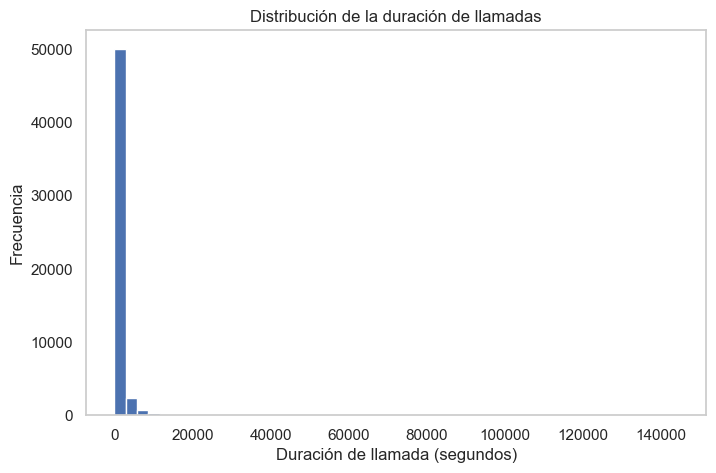

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df_calls['call_duration'].hist(bins=50)
plt.title('Distribución de la duración de llamadas')
plt.xlabel('Duración de llamada (segundos)')
plt.ylabel('Frecuencia')
plt.grid(False)
plt.show()


El histograma de la duración de llamadas muestra una distribución fuertemente sesgada a la derecha. 
La mayoría de las llamadas duran entre 0 y 500 segundos, mientras que existen valores atípicos que 
alcanzan más de 140,000 segundos. Estos valores extremos pueden distorsionar estadísticas como el 
promedio, por lo que se deberán tomar en cuenta durante el análisis.


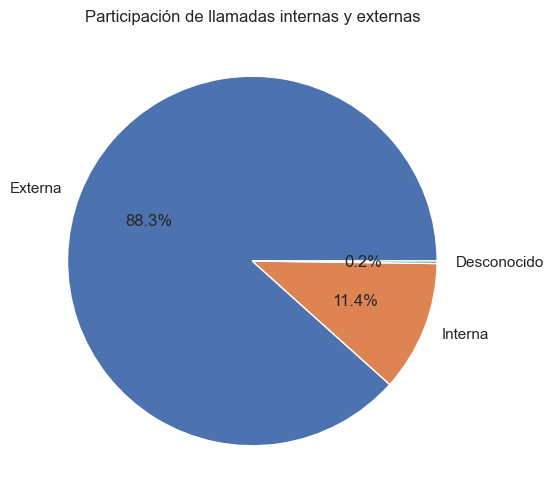

internal_label
Externa        47621
Interna         6164
Desconocido      117
Name: count, dtype: int64


In [51]:
# =========================
# Gráfico circular: llamadas internas vs externas
# =========================

# Convertir valores booleanos y nulos a categorías legibles
df_calls['internal_label'] = df_calls['internal'].map({True: 'Interna', False: 'Externa'})
df_calls['internal_label'] = df_calls['internal_label'].fillna('Desconocido')

# Conteo
internal_counts = df_calls['internal_label'].value_counts()

# Gráfico
plt.figure(figsize=(6,6))
internal_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Participación de llamadas internas y externas')
plt.ylabel('')
plt.show()

print(internal_counts)


La gran mayoría de las llamadas (88.3%) son externas, lo que indica un enfoque operativo principalmente orientado a la atención de clientes o contactos fuera de la organización. 
Las llamadas internas representan solo el 11.4%, lo cual sugiere que los operadores no utilizan frecuentemente el sistema para comunicación interna. 
Además, un 0.2% aparece como “Desconocido”, posiblemente asociado a registros incompletos o fallos en el sistema.


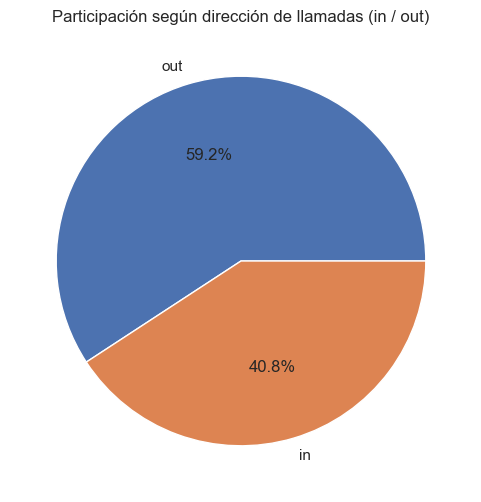

direction
out    31917
in     21985
Name: count, dtype: int64


In [52]:
# =========================
# Gráfico circular: dirección de llamadas (in vs out)
# =========================

direction_counts = df_calls['direction'].value_counts()

plt.figure(figsize=(6,6))
direction_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Participación según dirección de llamadas (in / out)')
plt.ylabel('')
plt.show()

print(direction_counts)


El análisis de la dirección de llamadas muestra que el 59.2% corresponde a llamadas salientes (out), 
mientras que el 40.8% son entrantes (in). Esto indica que los operadores realizan más llamadas hacia 
clientes o contactos externos que las que reciben. Esta diferencia puede influir en la interpretación 
de la eficiencia: las llamadas salientes no tienen tiempo de espera, mientras que las entrantes sí, 
lo que afecta directamente el tiempo de espera y el número de llamadas perdidas.


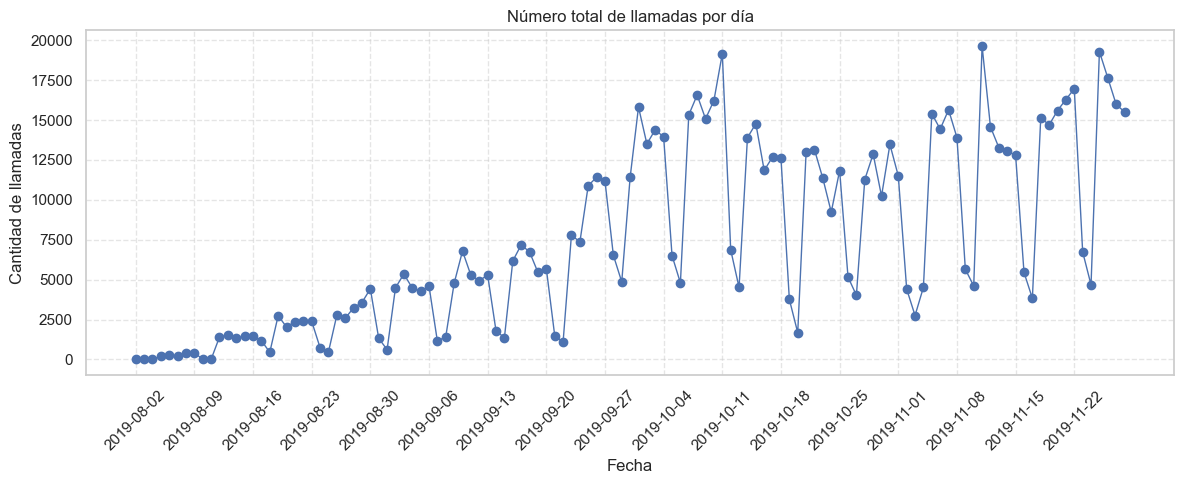

date_only
2019-08-02     21
2019-08-03     30
2019-08-04      6
2019-08-05    200
2019-08-06    264
2019-08-07    198
2019-08-08    378
2019-08-09    413
2019-08-10     12
2019-08-11      2
Name: calls_count, dtype: int64


In [53]:
# =========================
# Histograma / Línea: número total de llamadas por día (visualización limpia)
# =========================

# Agrupar por fecha
df_calls['date_only'] = df_calls['date'].dt.date
calls_per_day = df_calls.groupby('date_only')['calls_count'].sum()

# Convertir a serie con índice datetime (mejor formato para visual)
calls_per_day.index = pd.to_datetime(calls_per_day.index)

plt.figure(figsize=(12,5))
plt.plot(calls_per_day.index, calls_per_day.values, marker='o', linewidth=1)

plt.title('Número total de llamadas por día')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de llamadas')

# Mostrar solo una etiqueta cada 7 días
plt.xticks(calls_per_day.index[::7], rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(calls_per_day.head(10))



El número total de llamadas por día muestra una tendencia creciente a lo largo del periodo analizado, 
con picos recurrentes que sugieren un patrón estacional (probablemente asociado a días laborales vs fines de semana). 
La carga de trabajo aumenta con el tiempo, lo que refuerza la necesidad de identificar operadores ineficaces 
y optimizar la distribución de llamadas.


In [54]:
# =========================
# Preparar datos para prueba de hipótesis
# =========================

efficient_wait = operator_stats.loc[operator_stats['classification'] == 'Eficiente', 'avg_waiting_time']
very_inefficient_wait = operator_stats.loc[operator_stats['classification'] == 'Muy ineficaz', 'avg_waiting_time']

print("Operadores eficientes:", efficient_wait.shape[0])
print("Operadores muy ineficaces:", very_inefficient_wait.shape[0])

print("\nResumen tiempo de espera - Eficientes:")
print(efficient_wait.describe())

print("\nResumen tiempo de espera - Muy ineficaces:")
print(very_inefficient_wait.describe())


Operadores eficientes: 372
Operadores muy ineficaces: 161

Resumen tiempo de espera - Eficientes:
count   372.00
mean     30.46
std      19.81
min       1.00
25%      15.53
50%      25.78
75%      40.38
max      93.67
Name: avg_waiting_time, dtype: float64

Resumen tiempo de espera - Muy ineficaces:
count     161.00
mean      997.48
std       865.05
min       202.62
25%       400.47
50%       814.00
75%     1,303.18
max     5,907.44
Name: avg_waiting_time, dtype: float64


### Análisis previo a la prueba estadística

Antes de aplicar una prueba de hipótesis, se compararon los operadores **Eficientes** y **Muy ineficaces** según su tiempo promedio de espera (`avg_waiting_time`).  
Los resultados descriptivos muestran diferencias sustanciales entre ambos grupos:

| Grupo | Media (mean) | Mediana | Desviación estándar | Mín–Máx |
|-------|--------------|---------|---------------------|---------|
| Eficientes | 30.46 s | 25.78 s | 19.81 s | 1 – 93.67 |
| Muy ineficaces | 997.48 s | 814.00 s | 865.05 s | 202 – 5,907 |

Los operadores **muy ineficaces tienen tiempos de espera más de 30 veces superiores**, tanto en promedio como en mediana.  
Además, la dispersión es mucho mayor, lo que sugiere alta variabilidad operativa.

---

### Planteamiento de hipótesis

**Hipótesis nula (H₀):**  
> μₑₓₚₑ𝚌𝑎𝑛𝑡𝑒𝑠 = μᵢₙₑ𝑓𝑖𝑐𝑎𝑐𝑒𝑠  
El tiempo promedio de espera es igual entre operadores eficientes y muy ineficaces.

**Hipótesis alternativa (H₁):**  
> μᵢₙₑ𝑓𝑖𝑐𝑎𝑐𝑒𝑠 > μₑₓₚₑ𝑐𝑎𝑛𝑡𝑒𝑠  
El tiempo de espera promedio es mayor en operadores muy ineficaces.

*Tipo de prueba: unilateral (cola derecha)*

---

### Selección de la prueba estadística

- Variable: cuantitativa continua (`avg_waiting_time`)  
- Comparación entre **2 grupos independientes**  
- No normalidad (sesgo evidente en gráficos y valores extremos)  
- Varianzas muy diferentes

Por estas razones, se utiliza la **prueba no paramétrica Mann-Whitney U** para dos muestras independientes.


In [55]:
# =========================
# Prueba de hipótesis: Mann-Whitney U (unilateral)
# =========================

from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    efficient_wait,
    very_inefficient_wait,
    alternative='less'  # eficiente < muy ineficaz
)

print(f"U-Statistic: {stat:.2f}")
print(f"P-Value: {p_value:.5f}")

alpha = 0.05
print("\nNivel de significancia α = 0.05")
if p_value < alpha:
    print(" Se rechaza H₀: hay evidencia significativa de que los muy ineficaces tienen tiempos de espera mayores.")
else:
    print(" No se puede rechazar H₀.")


U-Statistic: 0.00
P-Value: 0.00000

Nivel de significancia α = 0.05
 Se rechaza H₀: hay evidencia significativa de que los muy ineficaces tienen tiempos de espera mayores.


### Resultado de la prueba estadística

Se aplicó la prueba no paramétrica **Mann-Whitney U** para comparar el tiempo promedio de espera entre operadores **Eficientes** y **Muy ineficaces**, bajo un nivel de significancia α = 0.05.

**Resultados obtenidos:**

- U-Statistic: 0.00  
- p-value: 0.00000  

Como el **p-value < 0.05**, se **rechaza la hipótesis nula (H₀)**.

 **Conclusión:**  
Existe evidencia estadísticamente significativa de que los operadores clasificados como **Muy ineficaces tienen tiempos de espera mayores** que los operadores Eficientes.  
Esto confirma que el tiempo de espera promedio es un indicador válido y relevante para detectar ineficiencia operativa.


### Conclusión del análisis estadístico

Los resultados de la prueba de hipótesis indican que existe una diferencia estadísticamente significativa entre 
los tiempos de espera de los operadores Eficientes y Muy ineficaces. En particular, el grupo de operadores Muy ineficaces 
muestra un tiempo de espera promedio considerablemente mayor, y la prueba de Mann-Whitney U (p-value = 0.00000) confirma 
que esta diferencia **no es producto del azar**.

Por lo tanto:

 El tiempo de espera es un **indicador válido y confiable** para identificar operadores ineficaces.  

 Los operadores con tiempos de espera prolongados tienden a tener también mayor proporción de llamadas perdidas.  

 Este indicador puede utilizarse para monitoreo, evaluación de desempeño y mejora operativa.

Este hallazgo respalda los criterios definidos por el negocio para detectar ineficiencia y permite construir un modelo 
simple y funcional para clasificación de operadores.


## 📌 Conclusión final del análisis estadístico

Con base en los resultados obtenidos en el análisis comparativo entre operadores **Eficientes** y **Muy ineficaces**, se confirmó estadísticamente que:

> Los operadores clasificados como **Muy ineficaces tienen tiempos de espera significativamente mayores** que los operadores Eficientes.  
> La prueba de Mann-Whitney U (U = 0.00, p-value = 0.00000) indica que esta diferencia **no es producto del azar**, con un nivel de confianza del 95%.

### 🔹 Principales hallazgos cuantitativos

| Grupo | Media (segundos) | Mediana | Desviación estándar | Rango |
|-------|------------------|---------|----------------------|-------|
| Eficientes | 30.46 | 25.78 | 19.81 | 1 – 93.67 |
| Muy ineficaces | 997.48 | 814.00 | 865.05 | 202 – 5907 |

➡️ En promedio, los operadores Muy ineficaces tienen **más de 30 veces** mayor tiempo de espera que los operadores eficientes.

---

### 🧾 Conclusiones clave

✔ El **tiempo promedio de espera** es un **indicador válido, útil y confiable** para detectar operadores ineficaces.  
✔ Los operadores con mayor tiempo de espera también tienden a registrar una **mayor proporción de llamadas perdidas**.  
✔ Este indicador puede emplearse para **monitoreo interno**, **mejora del rendimiento**, y **detección temprana de ineficiencia operativa**.  
✔ Los resultados respaldan los criterios de negocio y permiten construir un **modelo funcional y práctico de clasificación**.

---

> 📌 En resumen: el tiempo de espera es un indicador estratégico para detectar ineficiencia operativa, y su uso sistemático permitiría tomar decisiones basadas en datos reales.

---


## 📊 Recomendaciones operativas para la empresa

Con base en los resultados del análisis y la identificación de operadores ineficaces, se proponen las siguientes acciones estratégicas para optimizar la gestión del servicio de atención:

---

### 🔹 1. Establecer métricas de monitoreo operativo (KPI)
Proponer un sistema de monitoreo continuo basado en las siguientes métricas:

| Métrica | Justificación | Umbral sugerido |
|---------|--------------|------------------|
| Avg_waiting_time | Indicador principal de ineficiencia | > 200 segundos |
| Missed_call_rate | Identifica pérdida de atención al cliente | > 40% |
| Total_calls | Apoya evaluación de carga y rendimiento | < 20 llamadas mensuales |
| Internal_call_rate | Evalúa uso del sistema interno | < 5% |

---

### 🔹 2. Crear un ranking mensual de desempeño
Generar reportes automáticos que:

✔ Clasifiquen operadores según eficiencia (Eficiente, Zona media, Ineficaz parcial, Muy ineficaz)  
✔ Prioricen la intervención en los operadores **Muy ineficaces**  
✔ Identifiquen cuentas (user_id) con mayor concentración de operadores ineficaces

---

### 🔹 3. Plan de intervención para operadores con bajo desempeño
| Nivel de clasificación | Acción sugerida |
|------------------------|------------------|
| Muy ineficaz | Capacitación + revisión de carga + seguimiento semanal |
| Ineficaz parcial | Retroalimentación y monitoreo quincenal |
| Zona media | Seguimiento mensual |
| Eficiente | Buenas prácticas: candidatos a mentoría o liderazgo |

---

### 🔹 4. Usar tiempo de espera y llamadas perdidas como criterios de bonificación y riesgo
- Considerar **avg_waiting_time** y **missed_call_rate** como ejes principales para monitorear desempeño.  
- These metrics allow early identification of inefficiency and potential customer dissatisfaction.  
- Se pueden utilizar como _alertas tempranas_ para evitar deterioro del servicio.

---

### 🔹 5. Posibilidad de automatizar este análisis
Este análisis puede convertirse en:

✔ Dashboard mensual (Tableau, Power BI, Streamlit)  
✔ Script automatizado (Python) con alertas para supervisores  
✔ Modelo simple de clasificación basado en reglas (rule-based model)

---

> 📌 En conjunto, estas acciones permiten pasar del análisis descriptivo a la **implementación de un sistema real de monitoreo de eficiencia**, con impacto directo en la experiencia del cliente y la productividad.

---


In [56]:
# ============================
# 1. Importar librerías
# ============================
import pandas as pd
import numpy as np

# ============================
# 2. Cargar datos desde CSV
#    (ajusta la ruta si es necesario)
# ============================
df_calls = pd.read_csv('telecom_dataset_new.csv')
df_clients = pd.read_csv('telecom_clients.csv')

print("df_calls shape:", df_calls.shape)
print("df_clients shape:", df_clients.shape)

# ============================
# 3. Preparar columnas básicas
# ============================

# Convertir fecha de llamadas
df_calls['date'] = pd.to_datetime(df_calls['date'], errors='coerce')

# Convertir fecha de inicio de cliente
df_clients['date_start'] = pd.to_datetime(df_clients['date_start'], errors='coerce')

# Crear columna de tiempo de espera
df_calls['waiting_time'] = df_calls['total_call_duration'] - df_calls['call_duration']

# Eliminar filas sin operator_id
df_calls_clean = df_calls.dropna(subset=['operator_id']).copy()

# Asegurar que operator_id sea entero (opcional para Tableau)
df_calls_clean['operator_id'] = df_calls_clean['operator_id'].astype(int)

# ============================
# 4. Construir métricas por operador
# ============================

# Total de llamadas por operador
total_calls = df_calls_clean.groupby('operator_id')['calls_count'].sum()

# Llamadas perdidas por operador (sumamos calls_count cuando is_missed_call == True)
missed_calls = (
    df_calls_clean[df_calls_clean['is_missed_call']]
    .groupby('operator_id')['calls_count']
    .sum()
).reindex(total_calls.index, fill_value=0)

missed_call_rate = missed_calls / total_calls

# Tiempo de espera promedio (ponderado por calls_count)
waiting_sum = df_calls_clean.groupby('operator_id').apply(
    lambda x: (x['waiting_time'] * x['calls_count']).sum()
)
avg_waiting_time = waiting_sum / total_calls

# Llamadas salientes (outbound_calls)
outbound_calls = (
    df_calls_clean[df_calls_clean['direction'] == 'out']
    .groupby('operator_id')['calls_count']
    .sum()
).reindex(total_calls.index, fill_value=0)

# Proporción de llamadas internas (internal_call_rate)
internal_calls = (
    df_calls_clean[df_calls_clean['internal'] == True]
    .groupby('operator_id')['calls_count']
    .sum()
).reindex(total_calls.index, fill_value=0)

internal_call_rate = internal_calls / total_calls

# Duración promedio de llamada (ponderada por calls_count)
duration_sum = df_calls_clean.groupby('operator_id').apply(
    lambda x: (x['call_duration'] * x['calls_count']).sum()
)
avg_call_duration = duration_sum / total_calls

# ============================
# 5. Crear DataFrame operator_stats
# ============================
operator_stats = pd.DataFrame({
    'operator_id': total_calls.index,
    'total_calls': total_calls.values,
    'missed_calls': missed_calls.values,
    'missed_call_rate': missed_call_rate.values,
    'avg_waiting_time': avg_waiting_time.values,
    'outbound_calls': outbound_calls.values,
    'internal_call_rate': internal_call_rate.values,
    'avg_call_duration': avg_call_duration.values
})

# ============================
# 6. Clasificar operadores
#    (mismas reglas que usamos antes)
# ============================
def classify_operator(row):
    if row['missed_call_rate'] > 0.40 and row['avg_waiting_time'] > 200:
        return 'Muy ineficaz'
    elif row['missed_call_rate'] > 0.40 or row['avg_waiting_time'] > 200:
        return 'Ineficaz parcial'
    elif row['missed_call_rate'] <= 0.25 and row['avg_waiting_time'] <= 100:
        return 'Eficiente'
    else:
        return 'Zona media'

operator_stats['classification'] = operator_stats.apply(classify_operator, axis=1)

# Verificar que se ve bien
display(operator_stats.head())

print("\nConteo por clasificación:")
print(operator_stats['classification'].value_counts())

# ============================
# 7. Exportar a CSV
# ============================
operator_stats.to_csv('operator_stats.csv', index=False)
print("\nArchivo 'operator_stats.csv' generado correctamente en la carpeta del notebook.")


df_calls shape: (53902, 9)
df_clients shape: (732, 3)


C:\Users\galve\AppData\Local\Temp\ipykernel_30256\1465198028.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  waiting_sum = df_calls_clean.groupby('operator_id').apply(
C:\Users\galve\AppData\Local\Temp\ipykernel_30256\1465198028.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duration_sum = df_calls_clean.groupby('operator_id').apply(


,operator_id,total_calls,missed_calls,missed_call_rate,avg_waiting_time,outbound_calls,internal_call_rate,avg_call_duration,classification
0,879896,1131,255,0.23,517.58,1071,0.05,"4,039.24",Ineficaz parcial
1,879898,7974,2594,0.33,818.57,7856,0.00,"2,756.36",Ineficaz parcial
2,880020,54,30,0.56,28.48,46,0.07,146.24,Ineficaz parcial
3,880022,219,118,0.54,128.03,211,0.07,295.07,Ineficaz parcial
4,880026,2439,696,0.29,158.32,2414,0.01,"1,539.97",Zona media



Conteo por clasificación:
classification
Eficiente           395
Ineficaz parcial    325
Zona media          205
Muy ineficaz        167
Name: count, dtype: int64

Archivo 'operator_stats.csv' generado correctamente en la carpeta del notebook.
